
# Brazilian Airline Historical Series Analysis

#### Frederico Horst

### Data Sources:
- Historical domestic air fares by origin, destination and airline: available at [ANAC website](https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/todos-os-dados-abertos). Files used here are under the title "Voos e operações aéreas - Tarifas aéreas domésticas - filtros para acesso aos arquivos CSV"
- Inflation data, using IPCA index: available at [IBGE website](https://www.ibge.gov.br/estatisticas/economicas/precos-e-custos/9256-indice-nacional-de-precos-ao-consumidor-amplo.html?=&t=series-historicas)
- More information on air fares on [ANAC website](https://www.anac.gov.br/)


In [1]:
from files_processor import FilesProcessor

df, metrics, route_variability = FilesProcessor().process_files()
df = None
metrics.head(15)


/Users/fred/Projects/flight-fares-analysis/files_processor.py:121: RuntimeWarning: invalid value encountered in scalar divide
  variance = (weights * (values - average) ** 2).sum() / (weights.sum() - 1)
/Users/fred/Projects/flight-fares-analysis/files_processor.py:121: RuntimeWarning: invalid value encountered in scalar divide
  variance = (weights * (values - average) ** 2).sum() / (weights.sum() - 1)


,RouteAgg,Route,YearMonth,WeightedAverageFare,FareStdDev,TotalSeats,CoefficientVariation,IPCAIndex,WeightedAverageFareReal,FareStdDevReal
0,AJU >> BEL,AJU >> BEL,2010-07,517.963648,245.339151,159.0,0.473661,3111.05,1272.020689,602.506521
1,AJU >> BEL,AJU >> BEL,2010-08,474.473939,239.542604,165.0,0.504859,3112.29,1164.753949,588.036921
2,AJU >> BEL,AJU >> BEL,2010-09,586.108156,254.796107,141.0,0.434725,3126.29,1432.354077,622.680709
3,AJU >> BEL,AJU >> BEL,2010-10,496.748429,218.305165,191.0,0.439468,3149.74,1204.935173,529.530756
4,AJU >> BEL,AJU >> BEL,2010-11,477.686829,253.875096,205.0,0.531468,3175.88,1149.161501,610.742162
5,AJU >> BEL,AJU >> BEL,2010-12,316.785982,202.687740,224.0,0.639825,3195.89,757.314057,484.548822
6,AJU >> BEL,AJU >> BEL,2011-01,383.618131,261.305765,198.0,0.681161,3222.42,909.533849,619.539116
7,AJU >> BEL,AJU >> BEL,2011-02,526.375379,214.215954,145.0,0.406964,3248.20,1238.097055,503.861223
8,AJU >> BEL,AJU >> BEL,2011-03,444.167143,277.277417,189.0,0.624264,3273.86,1036.545117,647.077473
9,AJU >> BEL,AJU >> BEL,2011-04,540.949333,297.476856,150.0,0.549916,3299.07,1252.757307,688.911664


In [2]:
route_variability.sort_values(by='CoefficientVariation', ascending=False).head(5)

,RouteAgg,AverageFareReal,FareRealStdDev,MinFareReal,MaxFareReal,MonthsAvailable,TotalSeats,CoefficientVariation
8679,SBRP >> SBTC,69.659015,306.017536,2.102732,2144.093279,6.0,264.0,4.393079
6554,SBAX >> SNPD,229.385992,455.530764,64.768322,3918.818480,27.0,71.0,1.985870
2619,FOR >> SBMS,246.252821,358.629868,74.478557,4998.757652,47.0,1598.0,1.456348
6993,SBCN >> SBPB,1017.232527,1451.632288,367.418469,3976.827474,3.0,6.0,1.427041
4088,LDB >> MGF,195.351333,264.791065,43.835077,3787.027270,57.0,2235.0,1.355461


In [3]:
route_variability.sort_values(by='CoefficientVariation', ascending=True).head(5)

,RouteAgg,AverageFareReal,FareRealStdDev,MinFareReal,MaxFareReal,MonthsAvailable,TotalSeats,CoefficientVariation
8701,SBRP >> SNAB,613.605462,0.0,613.605462,613.605462,1.0,2.0,0.0
267,BEL >> SBTC,756.706361,0.0,756.706361,756.706361,1.0,2.0,0.0
8433,SBPJ >> SWHP,2346.846744,0.0,2346.846744,2346.846744,1.0,2.0,0.0
2196,CXJ >> SNPD,403.829550,0.0,403.829550,403.829550,1.0,2.0,0.0
9660,SLZ >> SSFB,677.424966,0.0,677.424966,677.424966,1.0,8.0,0.0


## Are fares getting more expensive over time?

Approach: build a seats-weighted national fare index by year — nominal and real (IPCA-deflated) —
from `metrics`, then test whether the trend is statistically significant (OLS slope on year).

**The 2009→2010 jump is a dated methodology change, not noise.** [ANAC Resolution 140/2010](https://www.gov.br/anac/pt-br/assuntos/regulados/empresas-aereas/Instrucoes-para-a-elaboracao-e-apresentacao-das-demonstracoes-contabeis/base-de-dados-estatisticos-do-transporte-aereo)
took effect in July 2010 and expanded fare monitoring to *all* domestic routes; before that, ANAC
published a narrower panel (the "Fare Yield Report", Jan 2002–Sep 2009). This shows up exactly on
schedule in the data: reported routes jump from ~65 to ~2,000+ between June and July 2010. A
national average spanning both eras is really comparing two different sampling methodologies, not
a clean price signal — so alongside the full-period trend, this notebook treats **2011-2025** (full
calendar years under the new, consistent methodology) as the more trustworthy window, and
cross-checks both with a fixed basket of routes present in every year.

Data now runs from Jan 2002 through May 2026 with no gaps; 2026 is excluded from the yearly
aggregation below since it's a partial year.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

metrics['Year'] = metrics['YearMonth'].str[:4].astype(int)

def weighted_average(values, weights):
    return (values * weights).sum() / weights.sum()

yearly = metrics[metrics['Year'] < 2026].groupby('Year').apply(lambda x: pd.Series({
    'AvgFareNominal': weighted_average(x['WeightedAverageFare'], x['TotalSeats']),
    'AvgFareReal': weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']),
    'RoutesReporting': x['RouteAgg'].nunique(),
}), include_groups=False).reset_index()
yearly


,Year,AvgFareNominal,AvgFareReal,RoutesReporting
0,2002,271.863695,1092.572666,63.0
1,2003,344.736919,1208.515390,57.0
2,2004,386.021970,1268.889050,75.0
3,2005,395.520775,1220.454915,67.0
4,2006,376.994494,1116.618607,67.0
5,2007,286.604523,817.832028,68.0
6,2008,417.739408,1127.160856,66.0
7,2009,315.432904,813.427614,66.0
8,2010,272.465600,665.147400,2608.0
9,2011,269.871732,620.092991,3317.0


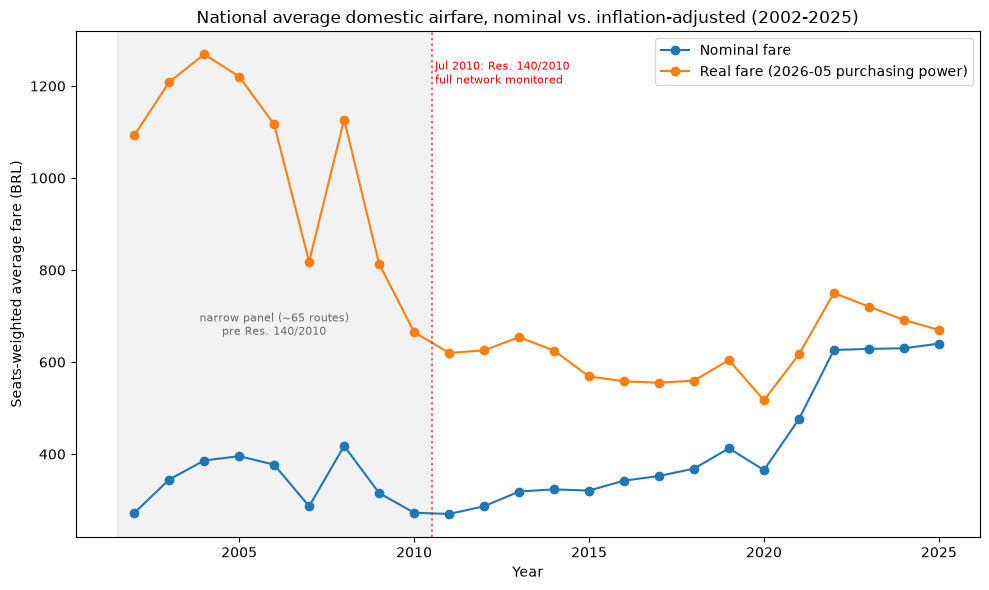

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yearly['Year'], yearly['AvgFareNominal'], marker='o', label='Nominal fare')
ax.plot(yearly['Year'], yearly['AvgFareReal'], marker='o',
        label=f"Real fare ({metrics['YearMonth'].max()} purchasing power)")
ax.axvspan(2001.5, 2010.5, color='grey', alpha=0.1)
ax.text(2006, yearly['AvgFareNominal'].max() * 1.03,
        'narrow panel (~65 routes)\npre Res. 140/2010', ha='center', fontsize=8, color='dimgrey')
ax.axvline(2010.5, color='red', linestyle=':', alpha=0.6)
ax.text(2010.6, yearly['AvgFareReal'].max() * 0.95,
        'Jul 2010: Res. 140/2010\nfull network monitored', fontsize=8, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Seats-weighted average fare (BRL)')
ax.set_title('National average domestic airfare, nominal vs. inflation-adjusted (2002-2025)')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
def trend_test(data, ycol, label):
    """OLS slope of ycol on Year: direction, fit and significance of the trend."""
    slope, intercept, r, p, se = stats.linregress(data['Year'], data[ycol])
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"{label}:\n  {slope:+.2f} BRL/year, R²={r**2:.3f}, p={p:.4f} ({sig} at 5%)\n")

trend_test(yearly, 'AvgFareNominal', 'Nominal fare, full period 2002-2025')
trend_test(yearly, 'AvgFareReal', 'Real fare, full period 2002-2025')
trend_test(yearly[yearly['Year'] >= 2011], 'AvgFareReal', 'Real fare, 2011-2025 (post Res. 140/2010, consistent methodology)')


Nominal fare, full period 2002-2025:
  +11.72 BRL/year, R²=0.476, p=0.0002 (significant at 5%)

Real fare, full period 2002-2025:
  -25.96 BRL/year, R²=0.555, p=0.0000 (significant at 5%)

Real fare, 2011-2025 (post Res. 140/2010, consistent methodology):
  +6.03 BRL/year, R²=0.167, p=0.1302 (not significant at 5%)



### Controlling for route-mix: fixed basket check

The trend above is computed over whichever routes happened to report each year. To check it isn't
an artifact of the route-mix shift around 2010, recompute the same seats-weighted real fare index
restricting to a **fixed basket** of routes present in *every* year of a window — same routes,
every year, so any remaining trend can't be explained by which routes are being averaged. This is
done both for the full 2002-2025 span and for the more trustworthy 2011-2025 span.


In [7]:
years_all = sorted(yearly['Year'].unique())
years_recent = [y for y in years_all if y >= 2011]
route_years = metrics[metrics['Year'] < 2026].groupby('RouteAgg')['Year'].apply(set)

basket_full = route_years[route_years.apply(lambda s: set(years_all).issubset(s))].index
basket_recent = route_years[route_years.apply(lambda s: set(years_recent).issubset(s))].index
print(f"Routes reporting every year 2002-2025: {len(basket_full)}")
print(f"Routes reporting every year 2011-2025: {len(basket_recent)}")

fixed_full = metrics[metrics['RouteAgg'].isin(basket_full) & (metrics['Year'] < 2026)].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('FixedBasketFareReal').reset_index()

fixed_recent = metrics[metrics['RouteAgg'].isin(basket_recent) & (metrics['Year'] >= 2011) & (metrics['Year'] < 2026)].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('FixedBasketFareReal').reset_index()

print()
trend_test(fixed_full, 'FixedBasketFareReal', f'Real fare, fixed basket of {len(basket_full)} routes, full period 2002-2025')
trend_test(fixed_recent, 'FixedBasketFareReal', f'Real fare, fixed basket of {len(basket_recent)} routes, 2011-2025')


Routes reporting every year 2002-2025: 44
Routes reporting every year 2011-2025: 1838

Real fare, fixed basket of 44 routes, full period 2002-2025:
  -33.72 BRL/year, R²=0.664, p=0.0000 (significant at 5%)

Real fare, fixed basket of 1838 routes, 2011-2025:
  +5.78 BRL/year, R²=0.154, p=0.1480 (not significant at 5%)



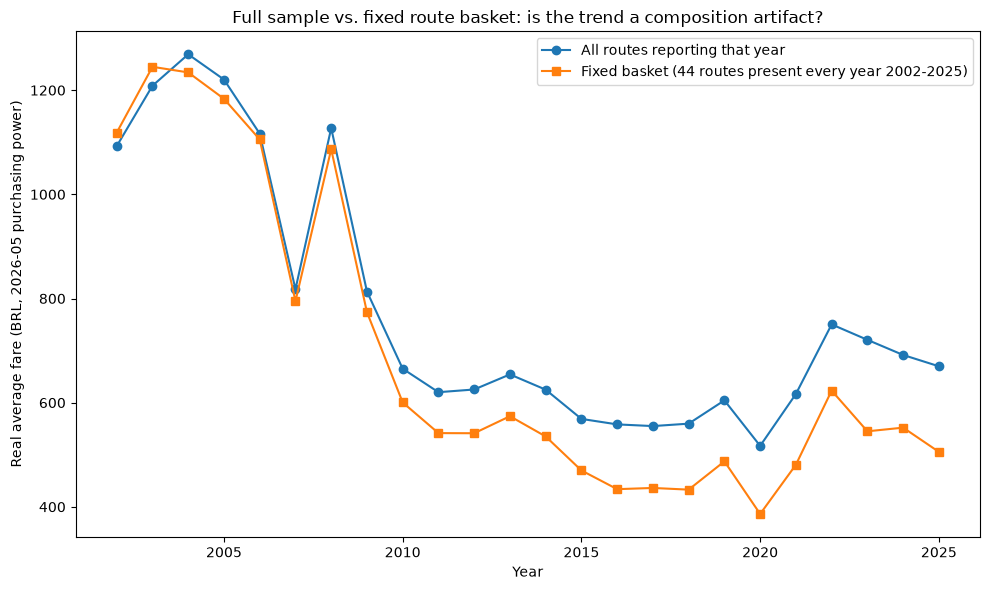

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yearly['Year'], yearly['AvgFareReal'], marker='o', label='All routes reporting that year')
ax.plot(fixed_full['Year'], fixed_full['FixedBasketFareReal'], marker='s',
        label=f'Fixed basket ({len(basket_full)} routes present every year 2002-2025)')
ax.set_xlabel('Year')
ax.set_ylabel(f"Real average fare (BRL, {metrics['YearMonth'].max()} purchasing power)")
ax.set_title('Full sample vs. fixed route basket: is the trend a composition artifact?')
ax.legend()
plt.tight_layout()
plt.show()


### Findings

- **Full period (2002-2025)**: real (inflation-adjusted) average fares are significantly lower now
  than in the 2002-2009 era — both in the full sample and in a fixed basket of the 44 routes
  present every year, so it isn't just a composition effect from adding cheaper regional routes
  after 2010. Nominal fares actually *rose* significantly over the same period (+R$12/year), so
  this finding depends entirely on deflating by IPCA.
- **Since the methodology stabilized (2011-2025)**: there is **no statistically significant trend**
  in real fares, either in the full sample or a fixed basket of 1,838 routes present every year
  since 2011 (p ≈ 0.13-0.15). Real fares moved in a roughly R$550-750 band — dipping in 2020
  (pandemic), spiking in 2022-2023, easing back in 2024-2025 — with no persistent up or down drift
  once the narrow pre-2010 panel is excluded.
- **Bottom line**: comparing today to 2002 in isolation suggests fares got cheaper, but most of
  that gap is explained by the July 2010 jump from a narrow trunk-route panel to full network
  monitoring (Resolution 140/2010), not a smooth multi-year price decline. Over the 15 years ANAC
  has consistently monitored the whole domestic network (2011-2025), real fares have essentially
  been flat, with no significant secular trend in either direction.

**Caveats**: this is a seats-weighted average across all reported routes/carriers, so it says
nothing about any specific route's price path (see `route_fare_variability.csv` / the
coefficient-of-variation cells above for route-level spread); 2026 is excluded as a partial year
(data available through May 2026 only).
